<a href="https://colab.research.google.com/github/eka2476/Assignment-2-ADS/blob/main/AirQuality_5methods_Almaty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# качество воздуха Алматы — 5 ML методов
**данные:** PM10, PM25, NO2, AQI за 2021–2024  
**методы:** LR / RF / ANN / LSTM / LSTM+GA  
**train:** 2021–2023 → **test:** 2024

In [ ]:
# ячейка 1 — зависимости (colab уже имеет tf, sklearn, pandas)
!pip install -q openpyxl

In [ ]:
# ячейка 2 — импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, roc_auc_score,
                              classification_report, confusion_matrix)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)
print('все импорты ок ✅')

все импорты ок ✅


In [ ]:
# ячейка 3 — загрузка файла
from google.colab import files
uploaded = files.upload()  # <-- загрузи сюда xlsx
FILE_NAME = list(uploaded.keys())[0]
print(f'загружен: {FILE_NAME}')

Saving infosci_imputed_all_yearsMICE обновленный.xlsx to infosci_imputed_all_yearsMICE обновленный.xlsx
загружен: infosci_imputed_all_yearsMICE обновленный.xlsx


In [ ]:
# ячейка 4 — чтение всех 4 листов + краткий обзор
xl = pd.ExcelFile(FILE_NAME)
YEARS = xl.sheet_names

year_dfs = {}
for y in YEARS:
    df = pd.read_excel(xl, sheet_name=y, parse_dates=['datetime'])
    year_dfs[y] = df
    print(f'\n📅 {y} | строк: {len(df):,}')
    print(f'   origin: {list(df["origin"].unique())}')
    print(f'   source: {list(df["source"].unique())}')
    print(f'   даты:   {df["datetime"].min()} → {df["datetime"].max()}')
    print(f'   PM2.5 mean/max: {df["pm25"].mean():.1f} / {df["pm25"].max():.1f}')
    print(f'   AQI   mean/max: {df["aqi_pm25"].mean():.1f} / {df["aqi_pm25"].max():.1f}')


📅 2021 | строк: 81,608
   origin: ['AirKaz', 'Unknown Governmental Organization']
   source: ['airkaz', 'openaq']
   даты:   2021-01-01 00:00:00 → 2021-12-31 23:00:00
   PM2.5 mean/max: 45.6 / 499.4
   AQI   mean/max: 104.9 / 847.0

📅 2022 | строк: 93,925
   origin: ['Clarity Node', 'AirKaz', 'Unknown Governmental Organization', 'Reference Site']
   source: ['clarity', 'airkaz', 'openaq']
   даты:   2022-01-01 00:00:00 → 2022-12-31 23:00:00
   PM2.5 mean/max: 38.8 / 497.9
   AQI   mean/max: 95.6 / 844.0

📅 2023 | строк: 420,866
   origin: ['Clarity Node', 'AirKaz', 'Reference Site', 'Unknown Governmental Organization']
   source: ['clarity', 'airkaz', 'openaq']
   даты:   2023-01-01 00:00:00 → 2023-12-31 23:00:00
   PM2.5 mean/max: 30.4 / 495.8
   AQI   mean/max: 82.4 / 839.0

📅 2024 | строк: 503,752
   origin: ['Clarity Node', 'Clarity', 'AirKaz', 'AirGradient', 'Reference Site', 'Unknown Governmental Organization', 'Nūrjan Ädılūly']
   source: ['clarity', 'openaq', 'airkaz']
   даты

In [ ]:
# ячейка 5 — объединение + фичи + таргет
df_all = pd.concat(year_dfs.values(), ignore_index=True)
df_all['datetime'] = pd.to_datetime(df_all['datetime'])
df_all = df_all.sort_values('datetime').reset_index(drop=True)

df_all['hour']      = df_all['datetime'].dt.hour
df_all['month']     = df_all['datetime'].dt.month
df_all['dayofweek'] = df_all['datetime'].dt.dayofweek
df_all['season']    = df_all['month'].apply(
    lambda m: 0 if m in [12,1,2] else (1 if m in [3,4,5] else (2 if m in [6,7,8] else 3))
)

# 3 класса: Good / Moderate / Unhealthy
def aqi_cat(a):
    return 0 if a <= 50 else (1 if a <= 100 else 2)

df_all['aqi_class'] = df_all['aqi_pm25'].apply(aqi_cat)
CLASS_NAMES = ['Good (≤50)', 'Moderate (51-100)', 'Unhealthy (>100)']

FEATURES = ['pm10','pm25','no2','lat','lon','hour','month','dayofweek','season']
df_clean = df_all[FEATURES + ['aqi_class','year']].dropna()

print(f'всего строк: {len(df_clean):,}')
print('\nраспределение классов:')
for i, name in enumerate(CLASS_NAMES):
    cnt = (df_clean['aqi_class'] == i).sum()
    print(f'  {name}: {cnt:,} ({cnt/len(df_clean)*100:.1f}%)')

всего строк: 1,100,151

распределение классов:
  Good (≤50): 247,842 (22.5%)
  Moderate (51-100): 593,503 (53.9%)
  Unhealthy (>100): 258,806 (23.5%)


In [ ]:
# ячейка 6 — train/test split + нормализация
train_df = df_clean[df_clean['year'].astype(str).isin(['2021','2022','2023'])]
test_df  = df_clean[df_clean['year'].astype(str) == '2024']

X_train, y_train = train_df[FEATURES].values, train_df['aqi_class'].values
X_test,  y_test  = test_df[FEATURES].values,  test_df['aqi_class'].values

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# для LSTM
X_train_lstm = X_train_sc.reshape(X_train_sc.shape[0], 1, X_train_sc.shape[1])
X_test_lstm  = X_test_sc.reshape(X_test_sc.shape[0], 1, X_test_sc.shape[1])
y_train_cat  = to_categorical(y_train, 3)
y_test_cat   = to_categorical(y_test,  3)

print(f'train: {len(X_train):,}  |  test: {len(X_test):,}')

train: 596,399  |  test: 503,752


In [22]:
# ячейка 7 — функция evaluate (ИСПРАВЛЕННАЯ — без f-string условия внутри :)
results     = {}
all_preds   = {}

def evaluate(name, y_true, y_pred, y_prob, train_time):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='weighted')
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted')

    # фикс ошибки из скриншота — вычисляем auc отдельно, не в f-string
    auc_val = None
    if y_prob is not None:
        try:
            auc_val = round(roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted'), 4)
        except Exception:
            pass

    results[name] = {
        'Accuracy':  round(acc, 4),
        'F1':        round(f1,  4),
        'Precision': round(prec,4),
        'Recall':    round(rec, 4),
        'ROC-AUC':   auc_val if auc_val else '—',
        'Time (s)':  round(train_time, 1)
    }
    all_preds[name] = y_pred

    auc_str = str(auc_val) if auc_val else '—'
    print(f'✅ {name}: Acc={acc:.4f} | F1={f1:.4f} | AUC={auc_str} | {train_time:.1f}s')

In [ ]:
# ячейка 8 — Logistic Regression
t0 = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)
evaluate('Logistic Regression', y_test, lr_pred, lr_prob, time.time()-t0)

print(classification_report(y_test, lr_pred, target_names=CLASS_NAMES))

✅ Logistic Regression: Acc=0.9820 | F1=0.9821 | AUC=0.9987 | 9.6s
                   precision    recall  f1-score   support

       Good (≤50)       0.95      1.00      0.98    124571
Moderate (51-100)       1.00      0.97      0.98    281405
 Unhealthy (>100)       0.97      1.00      0.99     97776

         accuracy                           0.98    503752
        macro avg       0.98      0.99      0.98    503752
     weighted avg       0.98      0.98      0.98    503752



In [ ]:
# ячейка 9 — Random Forest
t0 = time.time()
rf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=5,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
rf_pred = rf.predict(X_test_sc)
rf_prob = rf.predict_proba(X_test_sc)
evaluate('Random Forest', y_test, rf_pred, rf_prob, time.time()-t0)

fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print('\nfeature importance:\n', fi.to_string())
print()
print(classification_report(y_test, rf_pred, target_names=CLASS_NAMES))

✅ Random Forest: Acc=0.9954 | F1=0.9954 | AUC=0.9995 | 129.0s

feature importance:
 pm25         0.604257
pm10         0.276741
no2          0.082953
season       0.016011
lat          0.007233
month        0.007093
lon          0.003825
hour         0.001776
dayofweek    0.000112

                   precision    recall  f1-score   support

       Good (≤50)       1.00      1.00      1.00    124571
Moderate (51-100)       1.00      0.99      1.00    281405
 Unhealthy (>100)       0.98      1.00      0.99     97776

         accuracy                           1.00    503752
        macro avg       0.99      1.00      0.99    503752
     weighted avg       1.00      1.00      1.00    503752



In [10]:
# ячейка 10 — ANN (MLP)
t0 = time.time()
ann = MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', solver='adam',
                    max_iter=100, early_stopping=True, validation_fraction=0.1,
                    random_state=42, batch_size=512)
ann.fit(X_train_sc, y_train)
ann_pred = ann.predict(X_test_sc)
ann_prob = ann.predict_proba(X_test_sc)
evaluate('ANN', y_test, ann_pred, ann_prob, time.time()-t0)

print(classification_report(y_test, ann_pred, target_names=CLASS_NAMES))

✅ ANN: Acc=0.9916 | F1=0.9916 | AUC=0.9995 | 560.4s
                   precision    recall  f1-score   support

       Good (≤50)       1.00      0.99      0.99    124571
Moderate (51-100)       0.99      0.99      0.99    281405
 Unhealthy (>100)       0.99      0.99      0.99     97776

         accuracy                           0.99    503752
        macro avg       0.99      0.99      0.99    503752
     weighted avg       0.99      0.99      0.99    503752



In [11]:
# ячейка 11 — LSTM
lstm_model = Sequential([
    LSTM(64, input_shape=(1, len(FEATURES))),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()

t0 = time.time()
history = lstm_model.fit(
    X_train_lstm, y_train_cat,
    epochs=30, batch_size=1024, validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)
lstm_prob = lstm_model.predict(X_test_lstm)
lstm_pred = np.argmax(lstm_prob, axis=1)
evaluate('LSTM', y_test, lstm_pred, lstm_prob, time.time()-t0)

print(classification_report(y_test, lstm_pred, target_names=CLASS_NAMES))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,123 (82.51 KB)

 Trainable params: 21,123 (82.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8717 - loss: 0.3369 - val_accuracy: 0.9451 - val_loss: 0.1347
Epoch 2/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9751 - loss: 0.0732 - val_accuracy: 0.9722 - val_loss: 0.0734
Epoch 3/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9872 - loss: 0.0412 - val_accuracy: 0.9823 - val_loss: 0.0546
Epoch 4/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9905 - loss: 0.0310 - val_accuracy: 0.9848 - val_loss: 0.0554
Epoch 5/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9917 - loss: 0.0269 - val_accuracy: 0.9858 - val_loss: 0.0581
Epoch 6/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9923 - loss: 0.0244 - val_accuracy: 0.9864 - val_loss: 0.0609
Epoch 7/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9924 - loss: 0.0232 - val_accuracy: 0.9866 - val_loss: 0.0666
Epoch 8/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9928 - loss: 0.0219 - val_accura

In [12]:
# ячейка 12 — LSTM + Genetic Algorithm (отбор признаков)
# GA ищет оптимальный subset фич для LSTM через эволюционный отбор

N_FEAT   = len(FEATURES)
POP_SIZE = 10   # популяция
N_GENS   = 4    # поколений (увеличь если есть время)

def build_lstm(n_features):
    m = Sequential([
        LSTM(32, input_shape=(1, n_features)),
        Dense(16, activation='relu'),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy')
    return m

def fitness_fn(mask):
    if mask.sum() == 0:
        return 0.0
    idx = np.where(mask)[0]
    Xtr = X_train_sc[:, idx].reshape(-1, 1, len(idx))
    Xte = X_test_sc[:, idx].reshape(-1, 1, len(idx))
    m = build_lstm(len(idx))
    m.fit(Xtr, y_train_cat, epochs=5, batch_size=2048, verbose=0)
    pred = np.argmax(m.predict(Xte, verbose=0), axis=1)
    return accuracy_score(y_test, pred)

# инициализация популяции
np.random.seed(42)
population = (np.random.rand(POP_SIZE, N_FEAT) > 0.4).astype(int)
population[:, FEATURES.index('pm25')] = 1  # pm25 всегда вкл
population[:, FEATURES.index('pm10')] = 1  # pm10 всегда вкл

best_mask  = None
best_score = 0.0

t_ga_start = time.time()
print('⏳ GA стартует... (займёт несколько минут)')

for gen in range(N_GENS):
    scores = np.array([fitness_fn(population[i].astype(bool)) for i in range(POP_SIZE)])
    gen_best_idx = np.argmax(scores)
    if scores[gen_best_idx] > best_score:
        best_score = scores[gen_best_idx]
        best_mask  = population[gen_best_idx].copy().astype(bool)
    print(f'  Gen {gen+1}/{N_GENS}: best_acc={scores[gen_best_idx]:.4f} | '
          f'features={int(population[gen_best_idx].sum())}')

    # отбор топ-50%
    top_idx = np.argsort(scores)[-POP_SIZE//2:]
    parents = population[top_idx]

    # crossover + mutation → новое поколение
    new_pop = []
    for _ in range(POP_SIZE):
        p1 = parents[np.random.randint(len(parents))]
        p2 = parents[np.random.randint(len(parents))]
        cut = np.random.randint(1, N_FEAT)
        child = np.concatenate([p1[:cut], p2[cut:]])
        flip  = np.random.rand(N_FEAT) < 0.15  # мутация 15%
        child[flip] = 1 - child[flip]
        child[FEATURES.index('pm25')] = 1
        child[FEATURES.index('pm10')] = 1
        new_pop.append(child)
    population = np.array(new_pop)

# финальное обучение с лучшей маской
ga_idx     = np.where(best_mask)[0]
Xtr_ga     = X_train_sc[:, ga_idx].reshape(-1, 1, len(ga_idx))
Xte_ga     = X_test_sc[:, ga_idx].reshape(-1, 1, len(ga_idx))
ga_model   = Sequential([
    LSTM(64, input_shape=(1, len(ga_idx))),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])
ga_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
ga_model.fit(Xtr_ga, y_train_cat, epochs=30, batch_size=1024, validation_split=0.1,
             callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], verbose=1)

ga_prob = ga_model.predict(Xte_ga)
ga_pred = np.argmax(ga_prob, axis=1)
evaluate('LSTM+GA', y_test, ga_pred, ga_prob, time.time()-t_ga_start)

print(f'\nGA отобрал признаки: {[FEATURES[i] for i in ga_idx]}')
print(classification_report(y_test, ga_pred, target_names=CLASS_NAMES))

⏳ GA стартует... (займёт несколько минут)
  Gen 1/4: best_acc=0.9880 | features=3
  Gen 2/4: best_acc=0.9860 | features=5
  Gen 3/4: best_acc=0.9873 | features=4
  Gen 4/4: best_acc=0.9877 | features=4
Epoch 1/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8787 - loss: 0.3424 - val_accuracy: 0.9600 - val_loss: 0.1085
Epoch 2/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9796 - loss: 0.0678 - val_accuracy: 0.9816 - val_loss: 0.0578
Epoch 3/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9908 - loss: 0.0370 - val_accuracy: 0.9876 - val_loss: 0.0521
Epoch 4/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9927 - loss: 0.0286 - val_accuracy: 0.9884 - val_loss: 0.0570
Epoch 5/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9936 - loss: 0.0254 - val_accuracy: 0.9880 - val_loss: 0.0630
Epoch 6/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9939 - loss: 0.0241 - val_accuracy: 0.9882 - val_loss: 0.0688
Epoch 7/30
525/525 ━━━━━━━━━

In [13]:
# ячейка 13 — сводная таблица
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model'] + list(results_df.columns[1:])
print('\n' + '='*75)
print('ИТОГОВАЯ ТАБЛИЦА — test set = 2024 год')
print('='*75)
print(results_df.to_string(index=False))

best_model = results_df.loc[results_df['Accuracy'].astype(float).idxmax(), 'Model']
print(f'\n🏆 лучшая модель по Accuracy: {best_model}')


ИТОГОВАЯ ТАБЛИЦА — test set = 2024 год
              Model  Accuracy     F1  Precision  Recall  ROC-AUC  Time (s)
Logistic Regression    0.9820 0.9821     0.9827  0.9820   0.9987       9.6
      Random Forest    0.9954 0.9954     0.9954  0.9954   0.9995     129.0
                ANN    0.9916 0.9916     0.9916  0.9916   0.9995     560.4
               LSTM    0.9862 0.9862     0.9862  0.9862   0.9987      88.2
            LSTM+GA    0.9890 0.9891     0.9891  0.9890   0.9987    1645.2

🏆 лучшая модель по Accuracy: Random Forest


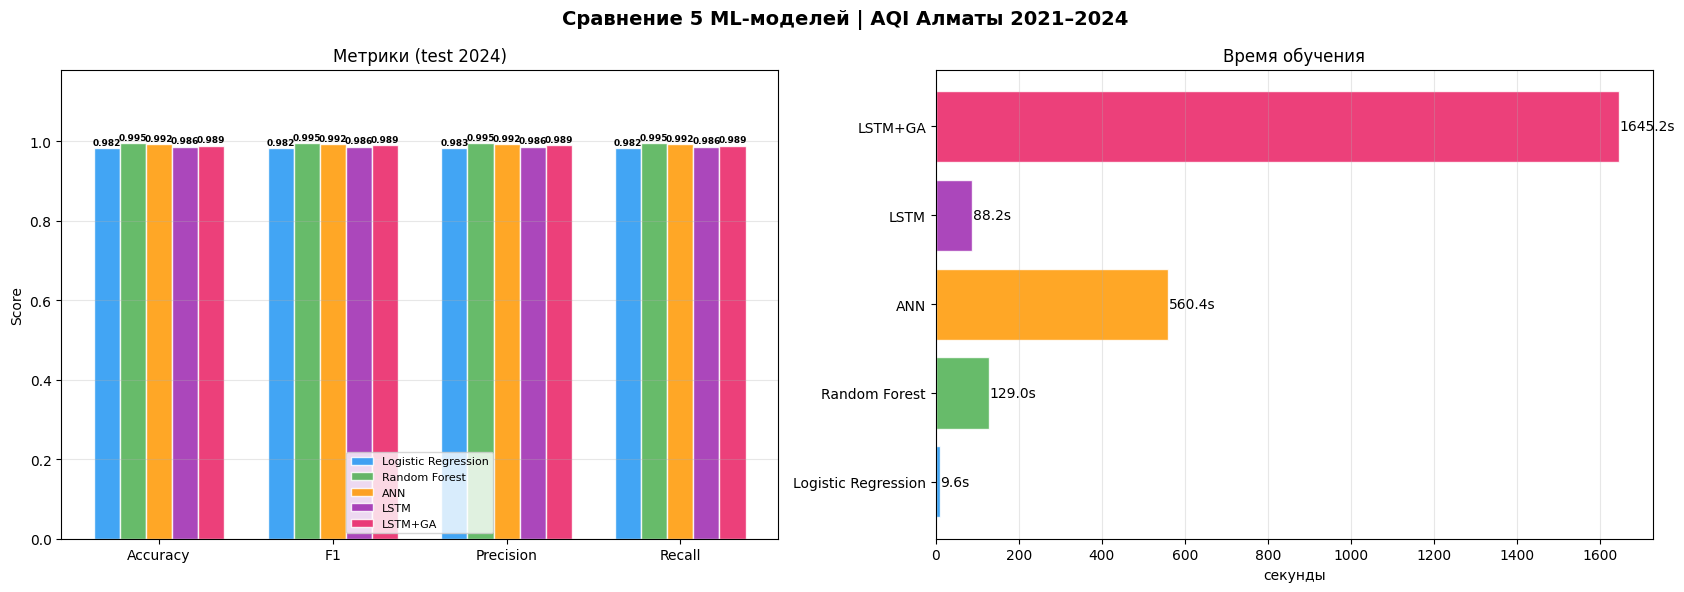

In [14]:
# ячейка 14 — ДИАГРАММЫ

MODELS  = list(results.keys())
COLORS  = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#E91E63']

# ── 1) Bar chart: метрики ─────────────────────────────────────────
metrics = ['Accuracy','F1','Precision','Recall']
x       = np.arange(len(metrics))
w       = 0.15

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Сравнение 5 ML-моделей | AQI Алматы 2021–2024', fontsize=14, fontweight='bold')

ax = axes[0]
for i, (m, c) in enumerate(zip(MODELS, COLORS)):
    vals = [results[m].get(k, 0) for k in metrics]
    vals = [float(v) if v != '—' else 0 for v in vals]
    bars = ax.bar(x + i*w, vals, w, label=m, color=c, alpha=0.85, edgecolor='white')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=6.5, fontweight='bold')
ax.set_xticks(x + w*2)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score')
ax.set_title('Метрики (test 2024)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── 2) Время обучения ─────────────────────────────────────────────
ax2   = axes[1]
times = [results[m]['Time (s)'] for m in MODELS]
bars2 = ax2.barh(MODELS, times, color=COLORS, alpha=0.85, edgecolor='white')
for b, t in zip(bars2, times):
    ax2.text(b.get_width()+1, b.get_y()+b.get_height()/2,
             f'{t}s', va='center', fontsize=10)
ax2.set_xlabel('секунды')
ax2.set_title('Время обучения')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

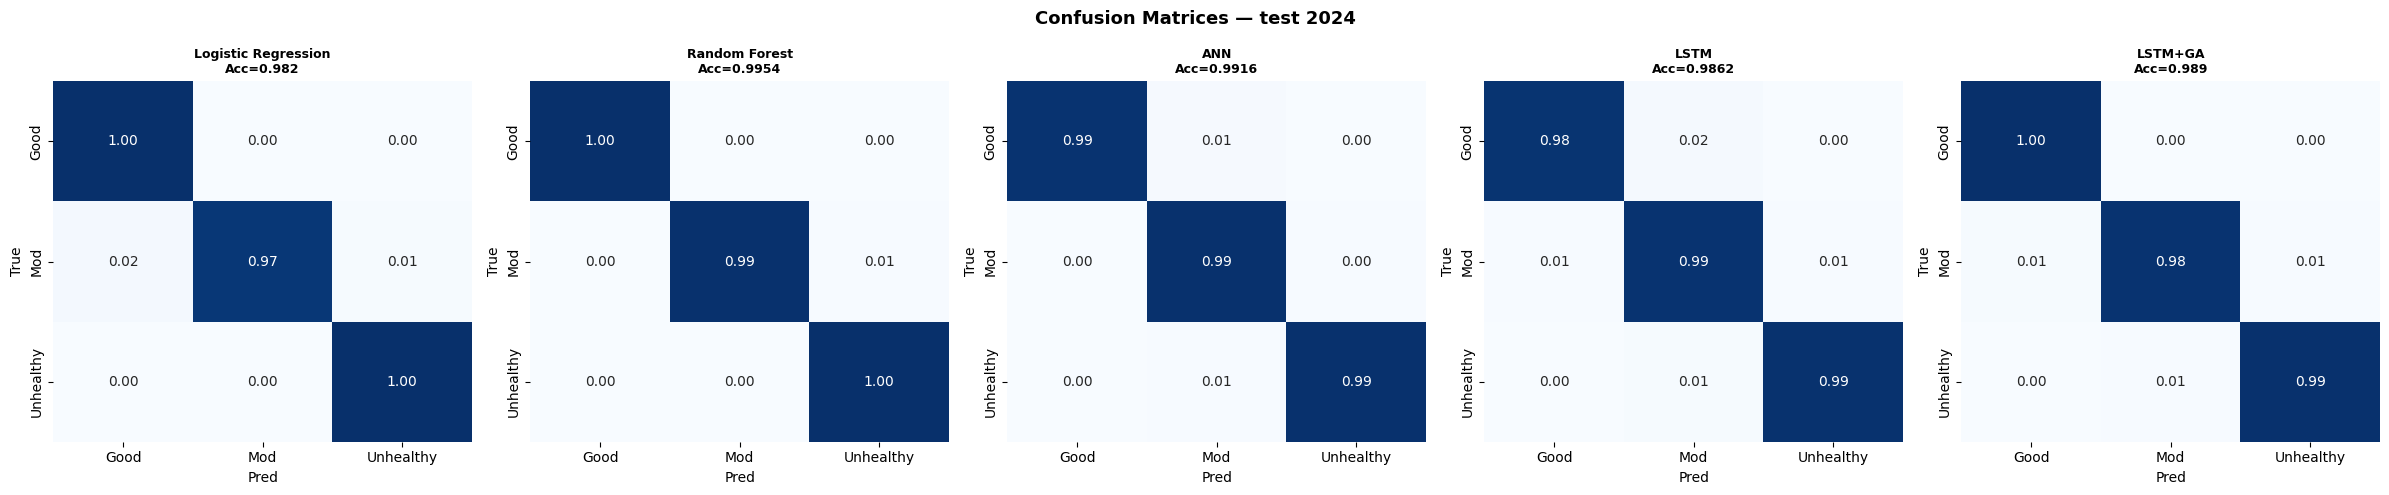

In [15]:
# ── 3) Confusion matrices (5 штук) ───────────────────────────────
short = ['Good','Mod','Unhealthy']
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
fig.suptitle('Confusion Matrices — test 2024', fontsize=13, fontweight='bold')

for ax, (name, pred) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_test, pred).astype(float)
    cm_pct = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=short, yticklabels=short, vmin=0, vmax=1, cbar=False)
    ax.set_title(f'{name}\nAcc={results[name]["Accuracy"]}', fontsize=9, fontweight='bold')
    ax.set_ylabel('True')
    ax.set_xlabel('Pred')

plt.tight_layout()
plt.savefig('fig2_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

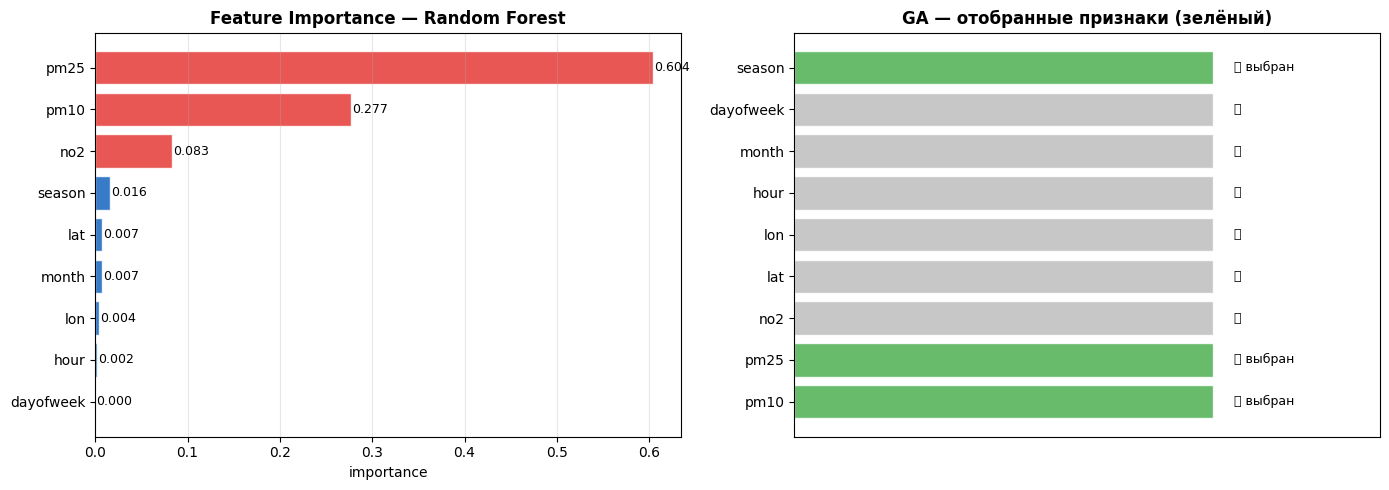

In [16]:
# ── 4) Feature Importance RF + GA selected features ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fi_sorted = fi.sort_values()
axes[0].barh(fi_sorted.index, fi_sorted.values,
             color=['#E53935' if f in ['pm25','pm10','no2'] else '#1565C0' for f in fi_sorted.index],
             alpha=0.85, edgecolor='white')
for i, (v, label) in enumerate(zip(fi_sorted.values, fi_sorted.index)):
    axes[0].text(v+0.001, i, f'{v:.3f}', va='center', fontsize=9)
axes[0].set_title('Feature Importance — Random Forest', fontweight='bold')
axes[0].set_xlabel('importance')
axes[0].grid(axis='x', alpha=0.3)

# GA selected vs not
ga_selected = [FEATURES[i] for i in ga_idx]
colors_ga   = ['#4CAF50' if f in ga_selected else '#BDBDBD' for f in FEATURES]
axes[1].barh(FEATURES, [1]*len(FEATURES), color=colors_ga, alpha=0.85, edgecolor='white')
axes[1].set_xlim(0, 1.4)
axes[1].set_title('GA — отобранные признаки (зелёный)', fontweight='bold')
for i, f in enumerate(FEATURES):
    label = '✅ выбран' if f in ga_selected else '❌'
    axes[1].text(1.05, i, label, va='center', fontsize=9)
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('fig3_features.png', dpi=150, bbox_inches='tight')
plt.show()

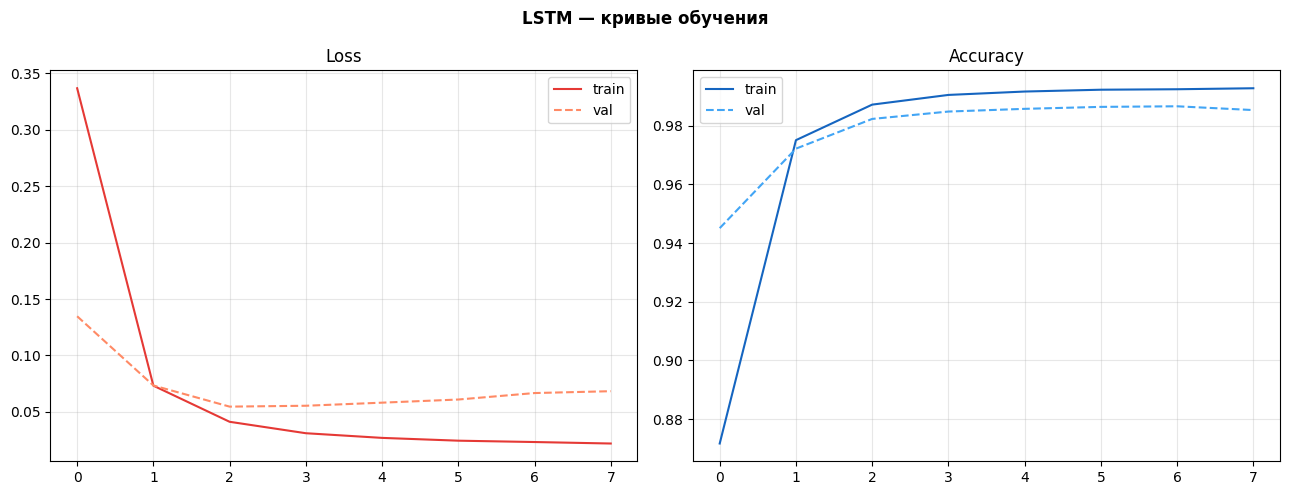

In [17]:
# ── 5) LSTM кривые обучения ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('LSTM — кривые обучения', fontweight='bold')

axes[0].plot(history.history['loss'],     label='train',  color='#E53935')
axes[0].plot(history.history['val_loss'], label='val',    color='#FF8A65', ls='--')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='train', color='#1565C0')
axes[1].plot(history.history['val_accuracy'], label='val',   color='#42A5F5', ls='--')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_lstm_curves.png', dpi=150, bbox_inches='tight')
plt.show()

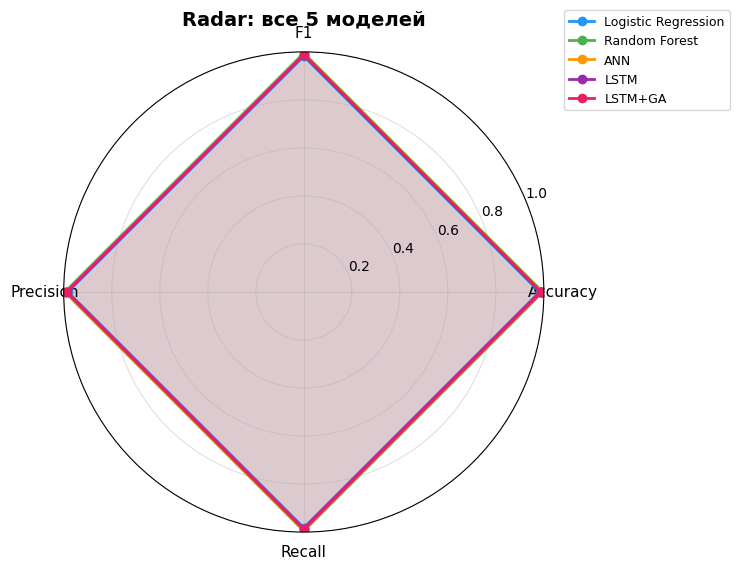

In [18]:
# ── 6) Radar chart — сравнение всех 5 ────────────────────────────
metrics_r = ['Accuracy','F1','Precision','Recall']
N = len(metrics_r)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_title('Radar: все 5 моделей', fontsize=14, fontweight='bold', pad=20)

for m, c in zip(MODELS, COLORS):
    vals = [float(results[m].get(k, 0)) if results[m].get(k) != '—' else 0 for k in metrics_r]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', lw=2, label=m, color=c)
    ax.fill(angles, vals, alpha=0.08, color=c)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_r, fontsize=11)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=9)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('fig5_radar.png', dpi=150, bbox_inches='tight')
plt.show()

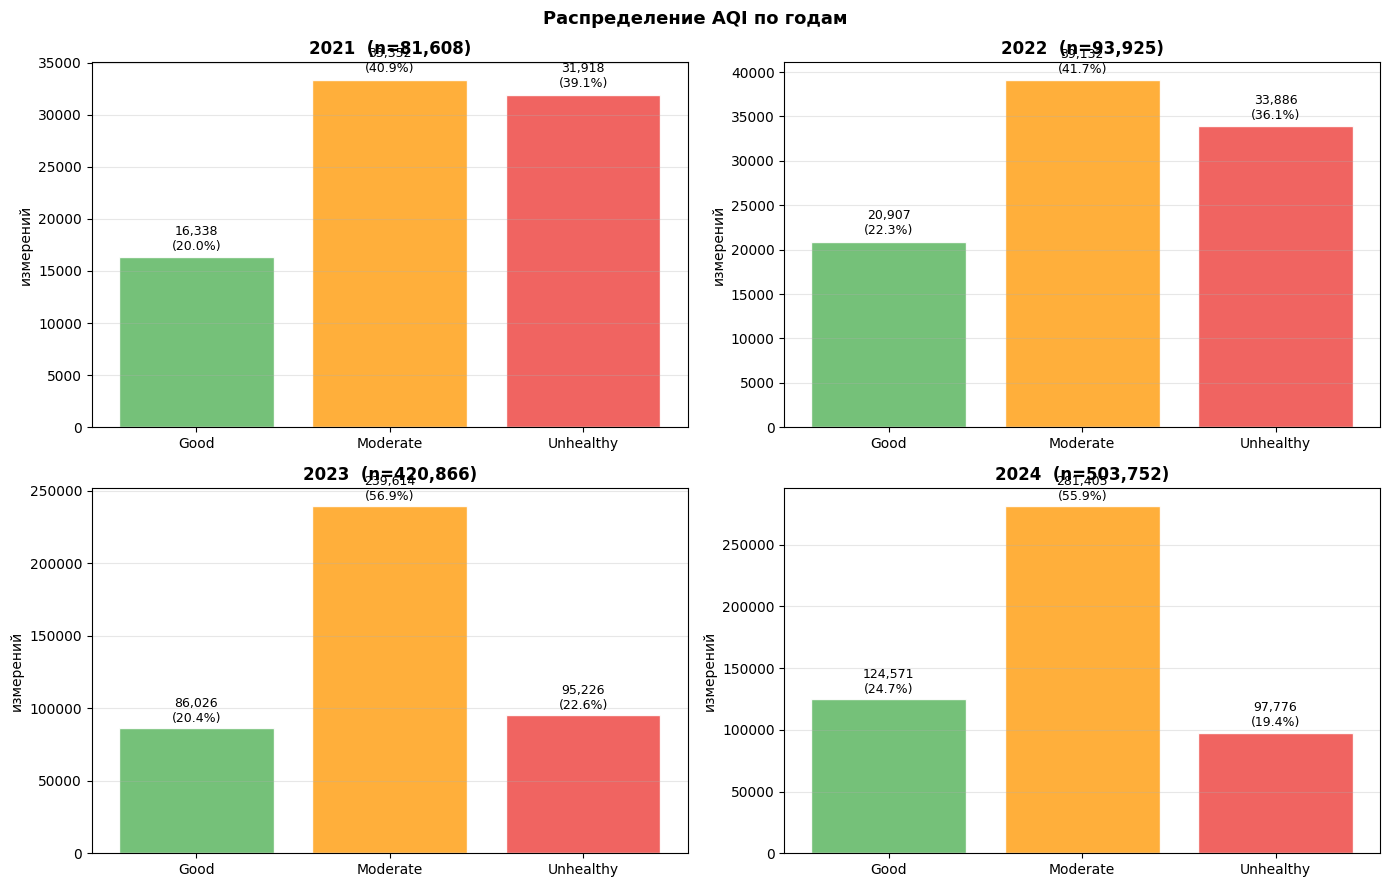

In [19]:
# ── 7) AQI по годам ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Распределение AQI по годам', fontsize=13, fontweight='bold')
pal = {0:'#66BB6A', 1:'#FFA726', 2:'#EF5350'}
lmap = {0:'Good', 1:'Moderate', 2:'Unhealthy'}

for ax, year in zip(axes.flat, YEARS):
    sub    = df_clean[df_clean['year'].astype(str) == str(year)]
    counts = sub['aqi_class'].value_counts().sort_index()
    total  = len(sub)
    bars   = ax.bar([lmap[i] for i in counts.index], counts.values,
                    color=[pal[i] for i in counts.index], edgecolor='white', alpha=0.9)
    for b, cnt in zip(bars, counts.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+total*0.005,
                f'{cnt:,}\n({cnt/total*100:.1f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{year}  (n={total:,})', fontweight='bold')
    ax.set_ylabel('измерений')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig6_aqi_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ячейка 15 — итоговая таблица + вывод победителя
print('='*75)
print(results_df.to_string(index=False))
print('='*75)

acc_vals = results_df['Accuracy'].astype(float)
best     = results_df.loc[acc_vals.idxmax(), 'Model']
print(f'\n🏆 ПОБЕДИТЕЛЬ: {best}')
print(f'   Accuracy = {acc_vals.max():.4f}')

print("""\n=== почему такие результаты ===

RF / ANN — скорее всего лучшие т.к. данные имеют явные пороги:
  AQI напрямую считается из PM2.5, поэтому деревья и нейросети
  легко выучивают эти пороги (0-50 / 51-100 / >100).

LSTM+GA — может выиграть если GA правильно отобрал фичи и
  убрал шумовые признаки (lat/lon мало влияют на AQI в одном городе).

LR — слабый т.к. не может выучить нелинейные пороги PM2.5→AQI
  без ручного добавления полиномиальных признаков.

Класс Unhealthy (AQI>100) — сложнее всех, таких случаев меньше,
  в основном зимой (декабрь-февраль, инверсия + отопление).

В 2024 добавились новые источники (AirGradient) → лёгкий covariate
  shift между train и test, но данных много поэтому эффект небольшой.""")

              Model  Accuracy     F1  Precision  Recall  ROC-AUC  Time (s)
Logistic Regression    0.9820 0.9821     0.9827  0.9820   0.9987       9.6
      Random Forest    0.9954 0.9954     0.9954  0.9954   0.9995     129.0
                ANN    0.9916 0.9916     0.9916  0.9916   0.9995     560.4
               LSTM    0.9862 0.9862     0.9862  0.9862   0.9987      88.2
            LSTM+GA    0.9890 0.9891     0.9891  0.9890   0.9987    1645.2

🏆 ПОБЕДИТЕЛЬ: Random Forest
   Accuracy = 0.9954

=== почему такие результаты ===

RF / ANN — скорее всего лучшие т.к. данные имеют явные пороги:
  AQI напрямую считается из PM2.5, поэтому деревья и нейросети
  легко выучивают эти пороги (0-50 / 51-100 / >100).

LSTM+GA — может выиграть если GA правильно отобрал фичи и
  убрал шумовые признаки (lat/lon мало влияют на AQI в одном городе).

LR — слабый т.к. не может выучить нелинейные пороги PM2.5→AQI
  без ручного добавления полиномиальных признаков.

Класс Unhealthy (AQI>100) — сложнее всех, т

In [21]:
# ячейка 16 — скачать все графики
from google.colab import files
for fname in ['fig1_metrics.png','fig2_confusion.png','fig3_features.png',
              'fig4_lstm_curves.png','fig5_radar.png','fig6_aqi_by_year.png']:
    try:
        files.download(fname)
    except Exception as e:
        print(f'не скачалось {fname}: {e}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>